In [35]:
#from sklearn.datasets import load_boston
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 

In [36]:
# NOTE: The Boston Housing dataset has been removed from scikit-learn (v1.2+) 
# due to ethical concerns. Specifically, it contains a variable ("B") that was 
# engineered under the flawed assumption that racial self-segregation 
# positively impacts housing prices. 
#
# The use of this dataset is strongly discouraged for production or 
# real-world decision-making applications.
#
# However, it may still be used for educational or research purposes 
# when studying model development, regression tasks, or ethical issues 
# in machine learning.
#
# The following code manually loads the dataset from the original source:

import pandas as pd
import numpy as np

# Load raw Boston Housing data
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# Combine lines to form full feature matrix
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Define column names
feature_names = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]

# Create DataFrame
df = pd.DataFrame(data, columns=feature_names)
df["MEDV"] = target  # Add target as 'MEDV' (Median home value)

# Check
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [37]:
# Data frame of input data  
X = pd.DataFrame(data, columns=feature_names)
print(X)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...    ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786  1.0  273.0   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875  1.0  273.0   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675  1.0  273.0   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889  1.0  273.0   
505  0.04741   0.0  11.93   0.0  0.573  6.030  80.8  2.5050  1.0  273.0   

     PTRATIO       B  LSTAT  
0       15.3  396.90   4.98  
1       17.8  396.90   9.14  
2       1

In [38]:
# Delete 'CHAS' column due to its low variance 
X = X.drop(['CHAS'],axis=1)
print(X.head())

      CRIM    ZN  INDUS    NOX     RM   AGE     DIS  RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31  0.538  6.575  65.2  4.0900  1.0  296.0     15.3   
1  0.02731   0.0   7.07  0.469  6.421  78.9  4.9671  2.0  242.0     17.8   
2  0.02729   0.0   7.07  0.469  7.185  61.1  4.9671  2.0  242.0     17.8   
3  0.03237   0.0   2.18  0.458  6.998  45.8  6.0622  3.0  222.0     18.7   
4  0.06905   0.0   2.18  0.458  7.147  54.2  6.0622  3.0  222.0     18.7   

        B  LSTAT  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  


In [39]:
# Display summary of dataframe 
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   NOX      506 non-null    float64
 4   RM       506 non-null    float64
 5   AGE      506 non-null    float64
 6   DIS      506 non-null    float64
 7   RAD      506 non-null    float64
 8   TAX      506 non-null    float64
 9   PTRATIO  506 non-null    float64
 10  B        506 non-null    float64
 11  LSTAT    506 non-null    float64
dtypes: float64(12)
memory usage: 47.6 KB
None


In [40]:
# Target variable  
y = pd.DataFrame(target)
print(y)

        0
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
..    ...
501  22.4
502  20.6
503  23.9
504  22.0
505  11.9

[506 rows x 1 columns]


In [41]:
# Delete 'CHAS' column
boston_df = df.drop(['CHAS'],axis=1)
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   NOX      506 non-null    float64
 4   RM       506 non-null    float64
 5   AGE      506 non-null    float64
 6   DIS      506 non-null    float64
 7   RAD      506 non-null    float64
 8   TAX      506 non-null    float64
 9   PTRATIO  506 non-null    float64
 10  B        506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


C:\Users\yongo\AppData\Local\Temp\ipykernel_14148\990639862.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(boston_df['MEDV'], bins=10)


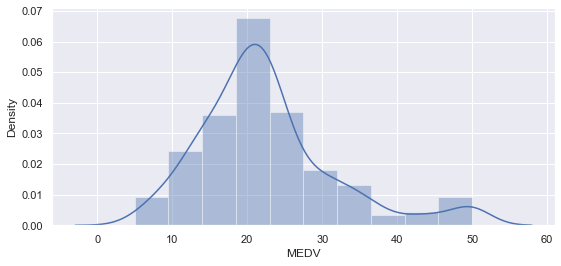

In [42]:
# Histogram of target variable 
sns.set(rc={'figure.figsize':(9, 4)})
sns.distplot(boston_df['MEDV'], bins=10)
plt.show()

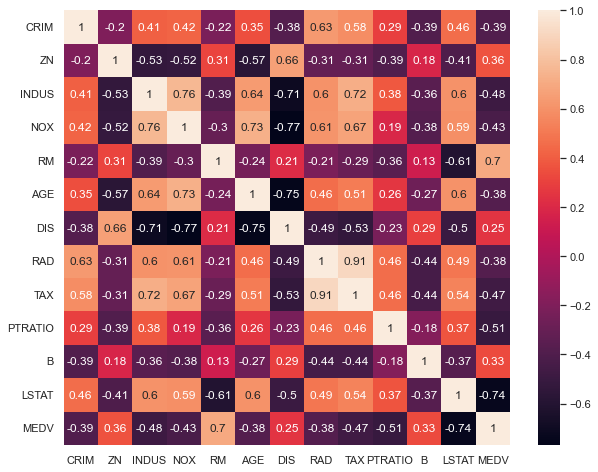

In [43]:
# Correlation coefficient 
correlation_matrix = boston_df.corr().round(2)
# Heat map of correlation coefficient 
sns.set(rc={'figure.figsize':(10, 8)})
sns.heatmap(data=correlation_matrix, annot=True)
plt.show()

In [44]:
# Data Splitting(7:3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [45]:
# Min_Max Scaler generator
scalerX = MinMaxScaler()
# Fit the Min_Max scaler to the training data
scalerX.fit(X_train)
# Transform the train data using the fitted scaler
X_train_norm = scalerX.transform(X_train)
# Transform the test data using the fitted scaler
X_test_norm = scalerX.transform(X_test)

In [46]:
print(X_train_norm)

[[3.53399869e-04 0.00000000e+00 1.64814815e-01 ... 8.08510638e-01
  9.98072925e-01 1.81439289e-01]
 [1.26723303e-03 0.00000000e+00 4.47777778e-01 ... 6.48936170e-01
  9.65337999e-01 1.93387052e-01]
 [2.12470480e-01 0.00000000e+00 6.42962963e-01 ... 8.08510638e-01
  4.48400020e-01 4.94581828e-01]
 ...
 [1.28429930e-02 0.00000000e+00 7.83333333e-01 ... 9.14893617e-01
  1.00000000e+00 4.54570714e-01]
 [1.10814419e-02 2.00000000e-01 1.19629630e-01 ... 4.25531915e-02
  9.88589685e-01 2.35343151e-01]
 [2.18998954e-02 0.00000000e+00 6.97777778e-01 ... 2.23404255e-01
  8.59779908e-01 3.13976104e-01]]


In [47]:
print(X_test_norm)

[[3.65071488e-01 0.00000000e+00 6.42962963e-01 ... 8.08510638e-01
  1.00000000e+00 4.94303973e-01]
 [1.98980913e-01 0.00000000e+00 6.42962963e-01 ... 8.08510638e-01
  3.26842132e-01 3.15365379e-01]
 [4.45578334e-04 0.00000000e+00 9.88888889e-02 ... 5.53191489e-01
  9.91505654e-01 1.72825785e-01]
 ...
 [5.49360096e-03 0.00000000e+00 2.02222222e-01 ... 5.10638298e-01
  9.75860845e-01 3.19533204e-02]
 [8.42578912e-02 0.00000000e+00 6.42962963e-01 ... 8.08510638e-01
  9.95892287e-01 1.39761045e-01]
 [1.07212685e-03 0.00000000e+00 7.96296296e-02 ... 5.74468085e-01
  9.91454942e-01 4.41789386e-02]]


In [48]:
# Min_Max Scaler generator
scalerY = MinMaxScaler()
# Fit the Min_Max scaler to the training data
scalerY.fit(y_train)
# Transform the train data using the fitted scaler
y_train_norm = scalerY.transform(y_train)
# Transform the test data using the fitted scaler
y_test_norm = scalerY.transform(y_test)





In [49]:
print(y_train_norm[0:10])

[[0.34666667]
 [0.36444444]
 [0.5       ]
 [0.13111111]
 [0.59111111]
 [0.34888889]
 [0.18888889]
 [0.69333333]
 [0.66444444]
 [0.18444444]]


In [50]:
print(y_test_norm[0:10])

[[0.07333333]
 [0.40222222]
 [0.37777778]
 [0.32444444]
 [0.56222222]
 [1.        ]
 [0.33111111]
 [0.39555556]
 [0.39777778]
 [0.11555556]]


In [51]:
# Modeling neural networks
model = Sequential()
model.add(Dense(60, activation='relu', input_shape=(12,)))
model.add(Dense(60, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(1))

C:\Users\yongo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
# Model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 60)             │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,301 (24.61 KB)

 Trainable params: 6,301 (24.61 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# Model compling
model.compile(optimizer='adam',
             loss='mse',
             metrics=['mae'])

In [54]:
# Model training
results = model.fit(X_train_norm, y_train_norm,
                    validation_data=(X_test_norm, y_test_norm),
                    epochs=200, batch_size=32)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1922 - mae: 0.3737 - val_loss: 0.0604 - val_mae: 0.1778
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0555 - mae: 0.1828 - val_loss: 0.0333 - val_mae: 0.1257
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0271 - mae: 0.1194 - val_loss: 0.0255 - val_mae: 0.1071
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0256 - mae: 0.1037 - val_loss: 0.0200 - val_mae: 0.0988
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0184 - mae: 0.0995 - val_loss: 0.0182 - val_mae: 0.0890
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0138 - mae: 0.0803 - val_loss: 0.0152 - val_mae: 0.0892
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0148 - mae: 0.0886 - val_loss: 0.0140 - val_mae: 0.0760
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0133 - mae: 0.0800 - val_loss: 0.0115 - val_mae: 0.0723
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.01

In [55]:
# Keys (metrics) stored in the trained model's history
print(results.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


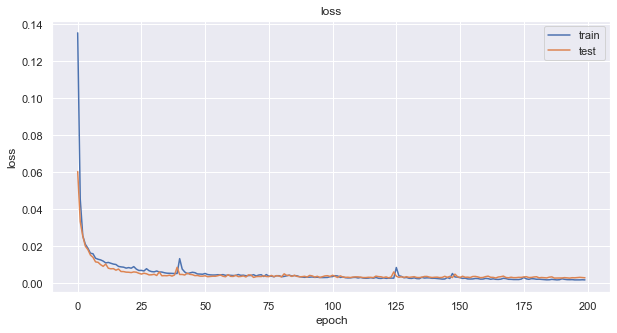

In [56]:
# Change in loss according to the number of epochs during training
plt.figure(figsize=(10, 5))
plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.title('loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

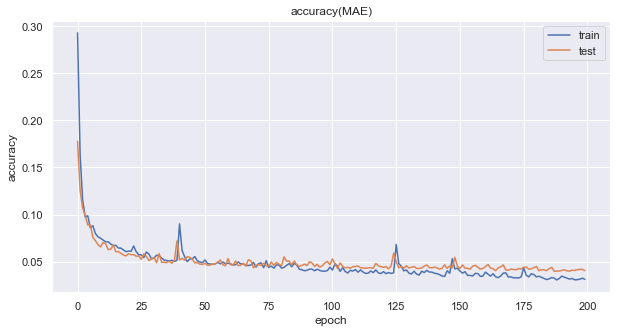

In [57]:
# Change in MAE according to the number of epochs during training
plt.figure(figsize=(10, 5))
plt.plot(results.history['mae'])
plt.plot(results.history['val_mae'])
plt.title('accuracy(MAE)')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [58]:
# Prediction on the test data
y_pred = model.predict(X_test_norm).flatten()
# Inverse transform of the predicted values
y_pred_inverse = scalerY.inverse_transform(y_pred.reshape(-1,1))
print(y_pred_inverse[0:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[ 9.038945]
 [29.840256]
 [25.203463]
 [18.016655]
 [27.041677]
 [48.057194]
 [20.276045]
 [22.54238 ]
 [20.649197]
 [14.15971 ]]


In [59]:
# Measure MAE
print('MAE: %.2f' % mean_absolute_error(y_test, y_pred_inverse))

MAE: 1.83


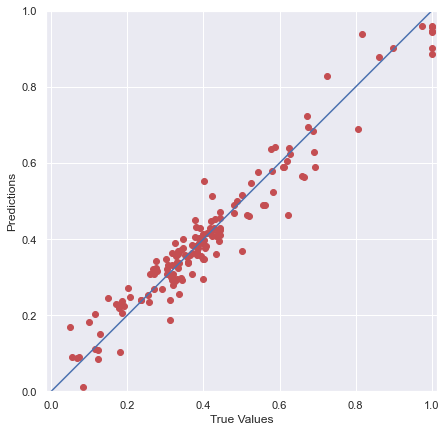

In [60]:
# Scatter plot of predicted values versus actual values
plt.figure(figsize=(7, 7))
plt.scatter(y_test_norm, y_pred, c='r')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.axis('equal')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.plot([0, 1], [0, 1])
plt.show()